<a href="https://colab.research.google.com/github/gauridhepe21-glitch/Python_AIML_Lab/blob/main/session18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ford_car_dataset.csv to ford_car_dataset.csv


In [8]:
print("\nFirst 10 Records")
print(df.head(10))


First 10 Records
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0


In [9]:
print("\nLast 5 Records")
print(df.tail())


Last 5 Records
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual    16700   Petrol  150  47.1   
17962   B-MAX  2014   7499       Manual    40700   Petrol   30  57.7   
17963   Focus  2015   9999       Manual     7010   Diesel   20  67.3   
17964      KA  2018   8299       Manual     5007   Petrol  145  57.7   
17965   Focus  2015   8299       Manual     5007   Petrol   22  57.7   

       engineSize  
17961         1.4  
17962         1.0  
17963         1.6  
17964         1.2  
17965         1.0  


In [10]:
print("\nShape :", df.shape)


Shape : (17966, 9)


In [11]:
print("\nData Types")
print(df.dtypes)


Data Types
model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object


In [12]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [13]:
print("\nDuplicate Rows :",
      df.duplicated().sum())



Duplicate Rows : 154


In [16]:
df = df.drop_duplicates()

In [17]:
print("\nSummary Statistics")
print(df.describe())

for col in ["price", "mileage", "year"]:
    print(f"\n{col.upper()}")
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())
    print("Mean    :", df[col].mean())
    print("Median  :", df[col].median())


Summary Statistics
               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  

PRICE
Minimum : 495
Maximum : 54995
Mean    : 12269.55631035

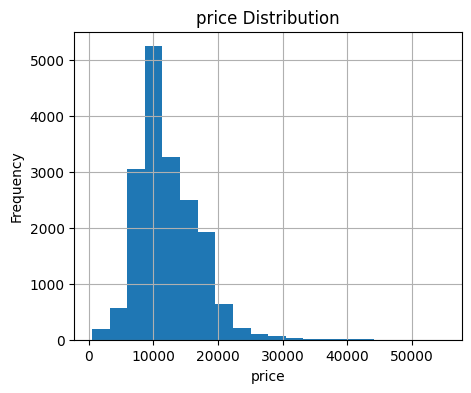

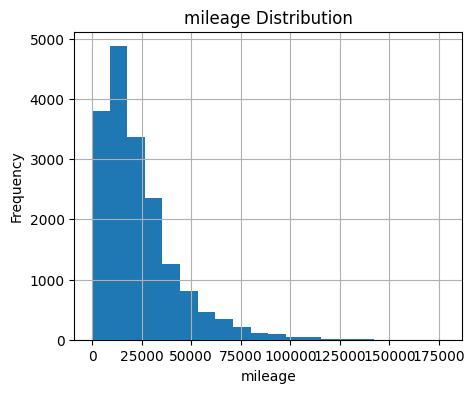

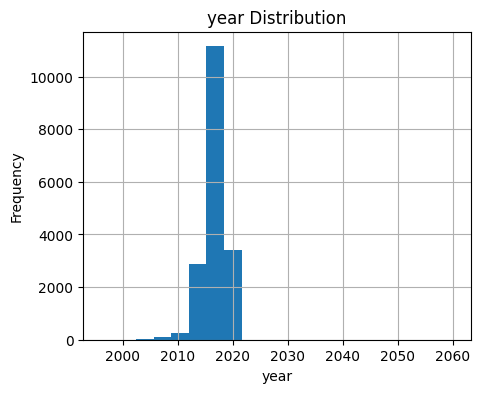

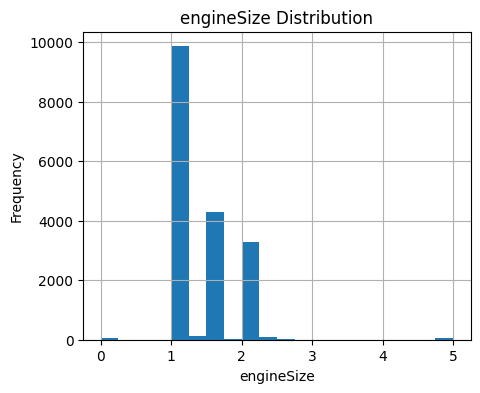

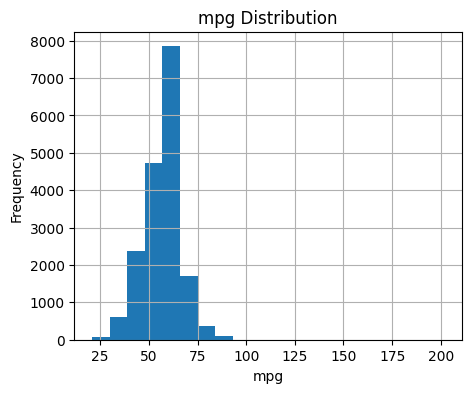

In [18]:
numeric_cols = ["price", "mileage", "year", "engineSize", "mpg"]

for col in numeric_cols:
    plt.figure(figsize=(5,4))
    plt.hist(df[col], bins=20)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

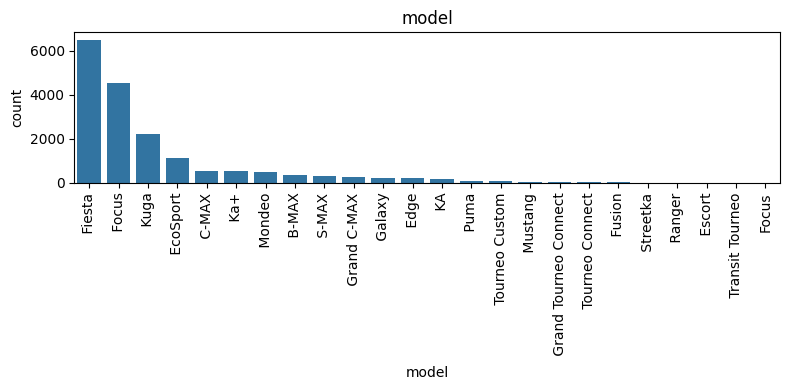

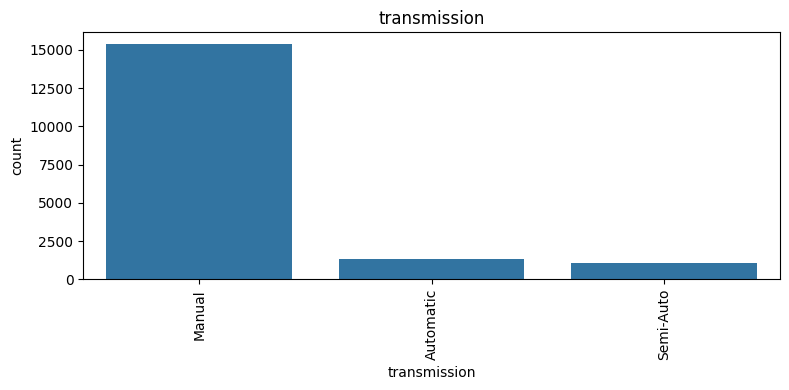

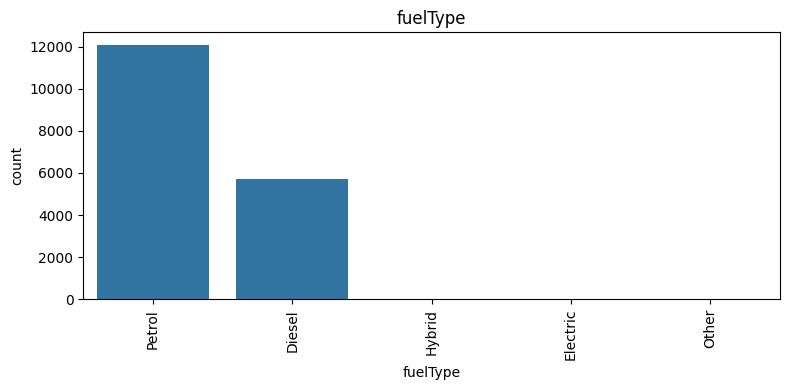

In [19]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.title(col)
    plt.tight_layout()
    plt.show()


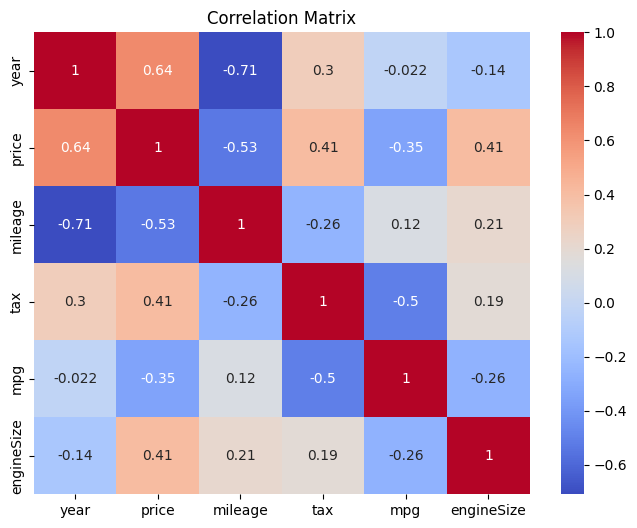

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [21]:
X = df.drop("price", axis=1)
y = df["price"]

print("\nIndependent Features")
print(X.columns.tolist())

print("\nDependent Feature")
print("price")


Independent Features
['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']

Dependent Feature
price


In [22]:
categorical = X.select_dtypes(include="object").columns

print("\nBefore Encoding")
print(X[categorical].head())

X = pd.get_dummies(X, columns=categorical, drop_first=True)

print("\nAfter Encoding")
print(X.head())



Before Encoding
     model transmission fuelType
0   Fiesta    Automatic   Petrol
1    Focus       Manual   Petrol
2    Focus       Manual   Petrol
3   Fiesta       Manual   Petrol
4   Fiesta    Automatic   Petrol

After Encoding
   year  mileage  tax   mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0  2017    15944  150  57.7         1.0         False            False   
1  2018     9083  150  57.7         1.0         False            False   
2  2017    12456  150  57.7         1.0         False            False   
3  2019    10460  145  40.3         1.5         False            False   
4  2019     1482  145  48.7         1.0         False            False   

   model_ Edge  model_ Escort  model_ Fiesta  ...  model_ Tourneo Connect  \
0        False          False           True  ...                   False   
1        False          False          False  ...                   False   
2        False          False          False  ...                   False   
3        False  

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["year", "mileage", "engineSize", "mpg"]

X[num_cols] = scaler.fit_transform(X[num_cols])

print("\nScaled Data (First 5 Rows)")
print(X.head())

print("\nPreprocessing Completed Successfully!")


Scaled Data (First 5 Rows)
       year   mileage  tax       mpg  engineSize  model_ C-MAX  \
0  0.067059 -0.382994  150 -0.020597   -0.810561         False   
1  0.554393 -0.736317  150 -0.020597   -0.810561         False   
2  0.067059 -0.562616  150 -0.020597   -0.810561         False   
3  1.041726 -0.665405  145 -1.737858    0.345325         False   
4  1.041726 -1.127749  145 -0.908836   -0.810561         False   

   model_ EcoSport  model_ Edge  model_ Escort  model_ Fiesta  ...  \
0            False        False          False           True  ...   
1            False        False          False          False  ...   
2            False        False          False          False  ...   
3            False        False          False           True  ...   
4            False        False          False           True  ...   

   model_ Tourneo Connect  model_ Tourneo Custom  model_ Transit Tourneo  \
0                   False                  False                   False   
1 